# DePSI example workflow


Data used in this example: [download link](https://figshare.com/ndownloader/files/54495791). (SLC images in zarr format)


A cropped SLC stack `nl_amsterdam_extended_s1_asc_t088.zarr`, geocoded, with h2ph value.


In [11]:
import numpy as np
import xarray as xr

from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as plc

from depsi.io import read_slc_stack
from depsi.classification import ps_selection, network_stm_selection
from depsi.point_quality import detect_outliers_stm, stm_partitioning, stm_add_incremental_recal_nad_nmad, detect_side_lobes
from depsi.network import stm_to_arcs

## Load the Zarr format SLC stack

In [2]:
slcs = read_slc_stack('../../../data/nl_amsterdam_extended_s1_asc_t088.zarr')
slcs

<xarray.Dataset> Size: 4GB
Dimensions:    (azimuth: 345, range: 1360, time: 440)
Coordinates:
  * azimuth    (azimuth) int64 3kB 4364 4365 4366 4367 ... 4705 4706 4707 4708
  * range      (range) int64 11kB 18998 18999 19000 19001 ... 20355 20356 20357
  * time       (time) datetime64[ns] 4kB 2015-05-03 2015-05-15 ... 2025-05-10
Data variables:
    h2ph       (azimuth, range, time) float32 826MB dask.array<chunksize=(345, 1360, 1), meta=np.ndarray>
    lat        (azimuth, range) float32 2MB dask.array<chunksize=(345, 1360), meta=np.ndarray>
    lon        (azimuth, range) float32 2MB dask.array<chunksize=(345, 1360), meta=np.ndarray>
    complex    (azimuth, range, time) complex64 2GB dask.array<chunksize=(345, 1360, 1), meta=np.ndarray>
    amplitude  (azimuth, range, time) float32 826MB dask.array<chunksize=(345, 1360, 1), meta=np.ndarray>
    phase      (azimuth, range, time) float32 826MB dask.array<chunksize=(345, 1360, 1), meta=np.ndarray>

In [3]:
# DEBUG ONLY
slcs = slcs.isel(time=slice(0, 100))

## PS point selection

In [4]:
stm = ps_selection(slcs,
                   method="nmad",
                   threshold=0.30,
                   output_chunks=1000,
                   mem_persist=False)
stm                

<xarray.Dataset> Size: 155MB
Dimensions:              (space: 75595, time: 100)
Coordinates:
  * time                 (time) datetime64[ns] 800B 2015-05-03 ... 2017-10-19
    azimuth              (space) int64 605kB dask.array<chunksize=(1000,), meta=np.ndarray>
    range                (space) int64 605kB dask.array<chunksize=(1000,), meta=np.ndarray>
  * space                (space) int64 605kB 0 1 2 3 ... 75591 75592 75593 75594
Data variables:
    h2ph                 (space, time) float32 30MB dask.array<chunksize=(1000, 100), meta=np.ndarray>
    lat                  (space) float32 302kB dask.array<chunksize=(1000,), meta=np.ndarray>
    lon                  (space) float32 302kB dask.array<chunksize=(1000,), meta=np.ndarray>
    complex              (space, time) complex64 60MB dask.array<chunksize=(1000, 100), meta=np.ndarray>
    amplitude            (space, time) float32 30MB dask.array<chunksize=(1000, 100), meta=np.ndarray>
    phase                (space, time) float32 30MB dask.array<chunksize=(1000, 100), meta=np.ndarray>
    time_selection_nmad  (space) float32 302kB dask.array<chunksize=(1000,), meta=np.ndarray>
    full_ts_nmad         (space) float32 302kB dask.array<chunksize=(1000,), meta=np.ndarray>
    full_ts_nad          (space) float32 302kB dask.array<chunksize=(1000,), meta=np.ndarray>
    pnt_class            (space) int8 76kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
Attributes:
    ps_selection_start_date:  20150503
    ps_selection_end_date:    20171019

## STM quality control (Optional)

In [5]:
# Outlier detection
stm = detect_outliers_stm(stm)
stm

<xarray.Dataset> Size: 185MB
Dimensions:              (space: 75595, time: 100)
Coordinates:
  * time                 (time) datetime64[ns] 800B 2015-05-03 ... 2017-10-19
    azimuth              (space) int64 605kB dask.array<chunksize=(1000,), meta=np.ndarray>
    range                (space) int64 605kB dask.array<chunksize=(1000,), meta=np.ndarray>
  * space                (space) int64 605kB 0 1 2 3 ... 75591 75592 75593 75594
Data variables:
    h2ph                 (space, time) float32 30MB dask.array<chunksize=(1000, 100), meta=np.ndarray>
    lat                  (space) float32 302kB dask.array<chunksize=(1000,), meta=np.ndarray>
    lon                  (space) float32 302kB dask.array<chunksize=(1000,), meta=np.ndarray>
    complex              (space, time) complex64 60MB dask.array<chunksize=(1000, 100), meta=np.ndarray>
    amplitude            (space, time) float32 30MB dask.array<chunksize=(1000, 100), meta=np.ndarray>
    phase                (space, time) float32 30MB dask.array<chunksize=(1000, 100), meta=np.ndarray>
    time_selection_nmad  (space) float32 302kB dask.array<chunksize=(1000,), meta=np.ndarray>
    full_ts_nmad         (space) float32 302kB dask.array<chunksize=(1000,), meta=np.ndarray>
    full_ts_nad          (space) float32 302kB dask.array<chunksize=(1000,), meta=np.ndarray>
    pnt_class            (space) int8 76kB dask.array<chunksize=(75595,), meta=np.ndarray>
    outliers             (space, time) float32 30MB dask.array<chunksize=(1000, 100), meta=np.ndarray>
Attributes:
    ps_selection_start_date:  20150503
    ps_selection_end_date:    20171019

## Network unwrapping

### Network point selection

In [6]:
stm_network = network_stm_selection(stm, min_dist=200, azimuth_spacing=20, range_spacing=5)
stm_network

<xarray.Dataset> Size: 1MB
Dimensions:              (space: 584, time: 100)
Coordinates:
  * time                 (time) datetime64[ns] 800B 2015-05-03 ... 2017-10-19
    azimuth              (space) int64 5kB dask.array<chunksize=(584,), meta=np.ndarray>
    range                (space) int64 5kB dask.array<chunksize=(584,), meta=np.ndarray>
  * space                (space) int64 5kB 21918 72884 10627 ... 39020 71626
Data variables:
    h2ph                 (space, time) float32 234kB dask.array<chunksize=(584, 100), meta=np.ndarray>
    lat                  (space) float32 2kB dask.array<chunksize=(584,), meta=np.ndarray>
    lon                  (space) float32 2kB dask.array<chunksize=(584,), meta=np.ndarray>
    complex              (space, time) complex64 467kB dask.array<chunksize=(584, 100), meta=np.ndarray>
    amplitude            (space, time) float32 234kB dask.array<chunksize=(584, 100), meta=np.ndarray>
    phase                (space, time) float32 234kB dask.array<chunksize=(584, 100), meta=np.ndarray>
    time_selection_nmad  (space) float32 2kB dask.array<chunksize=(584,), meta=np.ndarray>
    full_ts_nmad         (space) float32 2kB dask.array<chunksize=(584,), meta=np.ndarray>
    full_ts_nad          (space) float32 2kB dask.array<chunksize=(584,), meta=np.ndarray>
    pnt_class            (space) int8 584B dask.array<chunksize=(584,), meta=np.ndarray>
    outliers             (space, time) float32 234kB dask.array<chunksize=(584, 100), meta=np.ndarray>
Attributes:
    ps_selection_start_date:  20150503
    ps_selection_end_date:    20171019

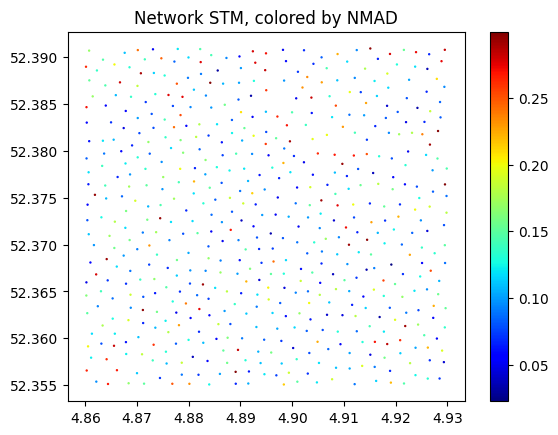

In [7]:
# Visualize results
colormap = cm.jet
fig, ax = plt.subplots()
plt.title("Network STM, colored by NMAD")
plt.scatter(stm_network['lon'], stm_network['lat'], c=stm_network['time_selection_nmad'], s=0.5, cmap=colormap)
plt.colorbar()

### Network arc generation

In [55]:
stm_network_arcs = stm_to_arcs(stm_network, network="redundant", max_length=0.004, difference="subtract")
stm_network_arcs

<xarray.Dataset> Size: 1MB
Dimensions:  (space: 2777, time: 100)
Coordinates:
    source   (space) int64 22kB 0 0 0 0 0 0 0 0 ... 556 557 558 560 565 568 571
    target   (space) int64 22kB 106 172 199 323 326 348 ... 563 581 570 580 578
  * time     (time) datetime64[ns] 800B 2015-05-03 2015-05-15 ... 2017-10-19
Dimensions without coordinates: space
Data variables:
    d_phase  (space, time) float32 1MB 0.9219 0.9534 1.403 ... 3.06 -0.6561

Text(0.5, 1.0, 'Network STM arcs, colored by average NMAD')

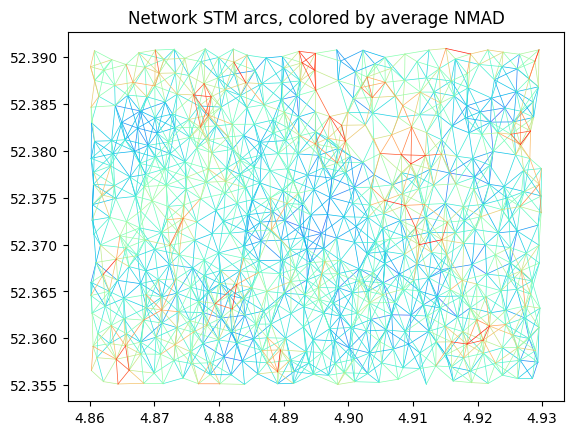

In [71]:
# x of sources and targets
xx = np.stack([stm_network.isel(space = stm_network_arcs['source'])['lon'].values,
               stm_network.isel(space = stm_network_arcs['target'])['lon'].values]).T
# y of sources and targets
yy = np.stack([stm_network.isel(space = stm_network_arcs['source'])['lat'].values,
               stm_network.isel(space = stm_network_arcs['target'])['lat'].values]).T
# Visualize created arcs
fig, ax = plt.subplots()
cmap = plt.cm.rainbow
norm = plc.Normalize(vmin=0, vmax=0.3)
mean_nmad = (stm_network.isel(space = stm_network_arcs['source'])['time_selection_nmad'].values + stm_network.isel(space = stm_network_arcs['target'])['time_selection_nmad'].values)/2
for i in range(stm_network_arcs.sizes["space"]):
    ax.plot(xx[i], yy[i], color=cmap(norm(mean_nmad[i])), linewidth=0.5)
plt.title("Network STM arcs, colored by average NMAD")

### Arc unwrapping

In [ ]:
# TODO: implement periodogram unwrapping and add it here

### Network integration